In [29]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

random_seed = 42
np.random.seed(random_seed )

In [30]:
#Loading the data
df = pd.read_csv('synthetic_heart_disease_dataset.csv')
print(f'shape:{df.shape}')
print(f"Duplicates:    {df.duplicated().sum()}")
print(f"Missing (NaN): {df.isnull().sum().sum()}")

shape:(50000, 21)
Duplicates:    0
Missing (NaN): 20109


In [46]:
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,1,78,157,26.4,2,1.0,0,2,1,...,0,1,1,0,104,99,71,165,200,0
1,35,0,73,163,33.0,2,1.0,2,1,2,...,0,1,1,0,111,72,60,145,206,0
2,79,0,88,152,32.3,2,1.0,1,1,1,...,0,0,1,0,116,102,78,148,208,0
3,75,1,106,171,37.4,2,2.0,1,1,0,...,0,1,0,0,171,92,109,105,290,1
4,34,0,65,191,18.5,1,2.0,0,2,0,...,1,0,0,0,164,67,108,116,220,1


In [32]:
df.tail()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
49995,74,Male,104,155,29.9,Current,NaN,Active,Average,Medium,...,0,0,0,0,127,80,83,174,248,1
49996,53,Male,95,163,35.8,Never,Low,Moderate,Healthy,Low,...,0,1,0,0,141,96,70,148,252,0
49997,38,Female,91,197,32.3,Former,Low,Moderate,Unhealthy,Low,...,0,0,0,0,178,94,90,75,235,0
49998,68,Male,115,152,18.6,Never,High,Moderate,Average,Medium,...,0,0,0,0,118,110,106,113,177,0
49999,53,Female,81,193,21.7,Never,Low,Moderate,Average,Low,...,0,0,0,0,108,111,87,172,280,1


In [33]:
df.describe()

,Age,Weight,Height,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.46406,84.547520,174.460000,28.984284,0.299620,0.199260,0.251660,0.400500,0.099280,139.299580,89.528800,84.449560,124.493020,224.556360,0.463460
std,14.43809,20.213257,14.420379,6.367494,0.458096,0.399448,0.433971,0.490005,0.299041,23.083544,17.258063,14.491325,31.691507,43.157467,0.498668
min,30.00000,50.000000,150.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,60.000000,60.000000,70.000000,150.000000,0.000000
25%,42.00000,67.000000,162.000000,23.500000,0.000000,0.000000,0.000000,0.000000,0.000000,119.000000,75.000000,72.000000,97.000000,187.000000,0.000000
50%,54.00000,85.000000,174.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.000000,90.000000,85.000000,125.000000,225.000000,0.000000
75%,67.00000,102.000000,187.000000,34.500000,1.000000,0.000000,1.000000,1.000000,0.000000,159.000000,104.000000,97.000000,152.000000,262.000000,1.000000
max,79.00000,119.000000,199.000000,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,109.000000,179.000000,299.000000,1.000000


In [34]:
df.columns

Index(['Age', 'Gender', 'Weight', 'Height', 'BMI', 'Smoking', 'Alcohol_Intake',
       'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes',
       'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting',
       'Cholesterol_Total', 'Heart_Disease'],
      dtype='object')

Heart_Disease
0    26827
1    23173
Name: count, dtype: int64
no heart disease: 26827  (53.7%)
heart disease:    23173  (46.3%)


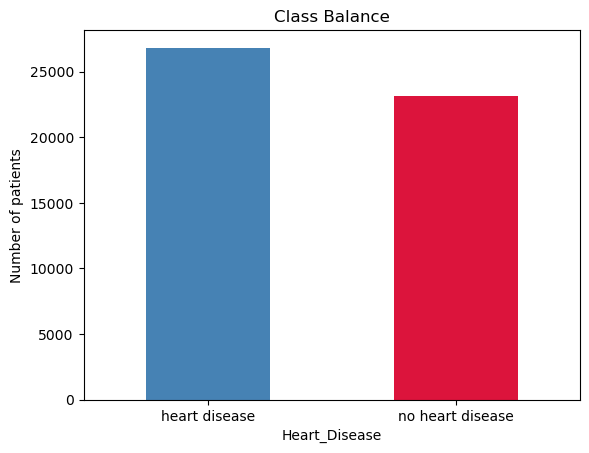

In [35]:
#inspecting class balance
counts = df['Heart_Disease'].value_counts()
print(counts)

print(f"no heart disease: {counts[0]}  ({counts[0] / len(df):.1%})")
print(f"heart disease:    {counts[1]}  ({counts[1] / len(df):.1%})")

counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0, 1], ['heart disease', 'no heart disease'], rotation=0)
plt.title('Class Balance')
plt.ylabel('Number of patients')
plt.show()

In [36]:
# Encoding
# Convert Gender: Male -> 1, Female -> 0
df['Diet'] = df['Diet'].map({'Healthy': 2, 'Average':1,'Unhealthy':0})
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,2,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,1,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,1,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,1,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,2,Low,...,1,0,0,0,164,67,108,116,220,1


In [37]:
df['Stress_Level'] = df['Stress_Level'].map({'High': 2, 'Medium':1,'Low':0})
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,2,1,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,1,2,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,1,1,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,1,0,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,2,0,...,1,0,0,0,164,67,108,116,220,1


In [38]:
df['Smoking'] = df['Smoking'].map({'Never': 2, 'Current':1,'Former':0})
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,2,NaN,Sedentary,2,1,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,2,Low,Active,1,2,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,2,NaN,Moderate,1,1,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,2,Moderate,Moderate,1,0,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,1,NaN,Sedentary,2,0,...,1,0,0,0,164,67,108,116,220,1


In [39]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female':0})
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,1,78,157,26.4,2,NaN,Sedentary,2,1,...,0,1,1,0,104,99,71,165,200,0
1,35,0,73,163,33.0,2,Low,Active,1,2,...,0,1,1,0,111,72,60,145,206,0
2,79,0,88,152,32.3,2,NaN,Moderate,1,1,...,0,0,1,0,116,102,78,148,208,0
3,75,1,106,171,37.4,2,Moderate,Moderate,1,0,...,0,1,0,0,171,92,109,105,290,1
4,34,0,65,191,18.5,1,NaN,Sedentary,2,0,...,1,0,0,0,164,67,108,116,220,1


In [40]:
# df['Alcohol_Intake'] = df['Alcohol_Intake'].map({'High':3, 'Moderate':2,'Low':1,'None':0})
df['Alcohol_Intake'] = df['Alcohol_Intake'].replace({'High': 3, 'Moderate': 2, 'Low': 1, 'None': 0})

# df.head()
df.tail()
# df.isnull().sum().sum()


C:\Users\ATZ COMPUTERS\AppData\Local\Temp\ipykernel_3008\2505764240.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Alcohol_Intake'] = df['Alcohol_Intake'].replace({'High': 3, 'Moderate': 2, 'Low': 1, 'None': 0})


,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
49995,74,1,104,155,29.9,1,NaN,Active,1,1,...,0,0,0,0,127,80,83,174,248,1
49996,53,1,95,163,35.8,2,1.0,Moderate,2,0,...,0,1,0,0,141,96,70,148,252,0
49997,38,0,91,197,32.3,0,1.0,Moderate,0,0,...,0,0,0,0,178,94,90,75,235,0
49998,68,1,115,152,18.6,2,3.0,Moderate,1,1,...,0,0,0,0,118,110,106,113,177,0
49999,53,0,81,193,21.7,2,1.0,Moderate,1,0,...,0,0,0,0,108,111,87,172,280,1


In [41]:
df['Physical_Activity'] = df['Physical_Activity'].map({'Active':2, 'Moderate':1,'Sedentary':0})
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,1,78,157,26.4,2,NaN,0,2,1,...,0,1,1,0,104,99,71,165,200,0
1,35,0,73,163,33.0,2,1.0,2,1,2,...,0,1,1,0,111,72,60,145,206,0
2,79,0,88,152,32.3,2,NaN,1,1,1,...,0,0,1,0,116,102,78,148,208,0
3,75,1,106,171,37.4,2,2.0,1,1,0,...,0,1,0,0,171,92,109,105,290,1
4,34,0,65,191,18.5,1,NaN,0,2,0,...,1,0,0,0,164,67,108,116,220,1


In [42]:
# Calculate skewness for people with and without heart disease
skew_hd = df[df['Heart_Disease'] == 1]['Alcohol_Intake'].skew()
skew_no_hd = df[df['Heart_Disease'] == 0]['Alcohol_Intake'].skew()

print(f"Skew for Heart Disease (1): {skew_hd:.4f}")
print(f"Skew for No Heart Disease (0): {skew_no_hd:.4f}")

Skew for Heart Disease (1): 0.6144
Skew for No Heart Disease (0): 0.6232


In [43]:
df['Alcohol_Intake'] = df['Alcohol_Intake'].fillna(
    df.groupby('Heart_Disease')['Alcohol_Intake'].transform('median')
)

In [44]:
df.isnull().sum().sum()

0

In [45]:
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,1,78,157,26.4,2,1.0,0,2,1,...,0,1,1,0,104,99,71,165,200,0
1,35,0,73,163,33.0,2,1.0,2,1,2,...,0,1,1,0,111,72,60,145,206,0
2,79,0,88,152,32.3,2,1.0,1,1,1,...,0,0,1,0,116,102,78,148,208,0
3,75,1,106,171,37.4,2,2.0,1,1,0,...,0,1,0,0,171,92,109,105,290,1
4,34,0,65,191,18.5,1,2.0,0,2,0,...,1,0,0,0,164,67,108,116,220,1


In [18]:
df.tail()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
49995,74,1,104,155,29.9,1,2.0,2,1,1,...,0,0,0,0,127,80,83,174,248,1
49996,53,1,95,163,35.8,2,1.0,1,2,0,...,0,1,0,0,141,96,70,148,252,0
49997,38,0,91,197,32.3,0,1.0,1,0,0,...,0,0,0,0,178,94,90,75,235,0
49998,68,1,115,152,18.6,2,3.0,1,1,1,...,0,0,0,0,118,110,106,113,177,0
49999,53,0,81,193,21.7,2,1.0,1,1,0,...,0,0,0,0,108,111,87,172,280,1


no heart disease: 26827  (53.7%)
heart disease:    23173  (46.3%)


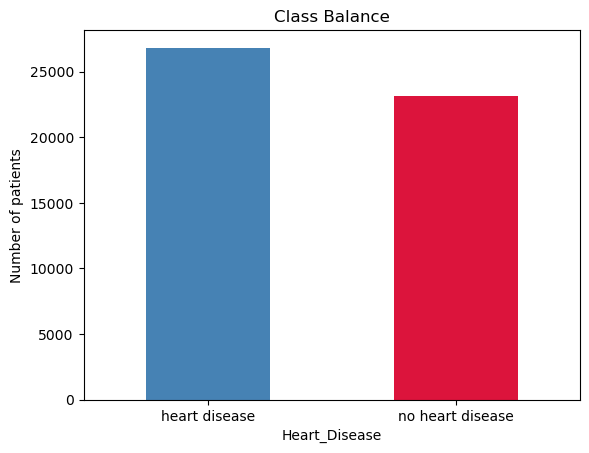

In [19]:
counts = df['Heart_Disease'].value_counts()

print(f"no heart disease: {counts[0]}  ({counts[0] / len(df):.1%})")
print(f"heart disease:    {counts[1]}  ({counts[1] / len(df):.1%})")

counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0, 1], ['heart disease', 'no heart disease'], rotation=0)
plt.title('Class Balance')
plt.ylabel('Number of patients')
plt.show()

In [20]:
df.columns

Index(['Age', 'Gender', 'Weight', 'Height', 'BMI', 'Smoking', 'Alcohol_Intake',
       'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes',
       'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting',
       'Cholesterol_Total', 'Heart_Disease'],
      dtype='object')

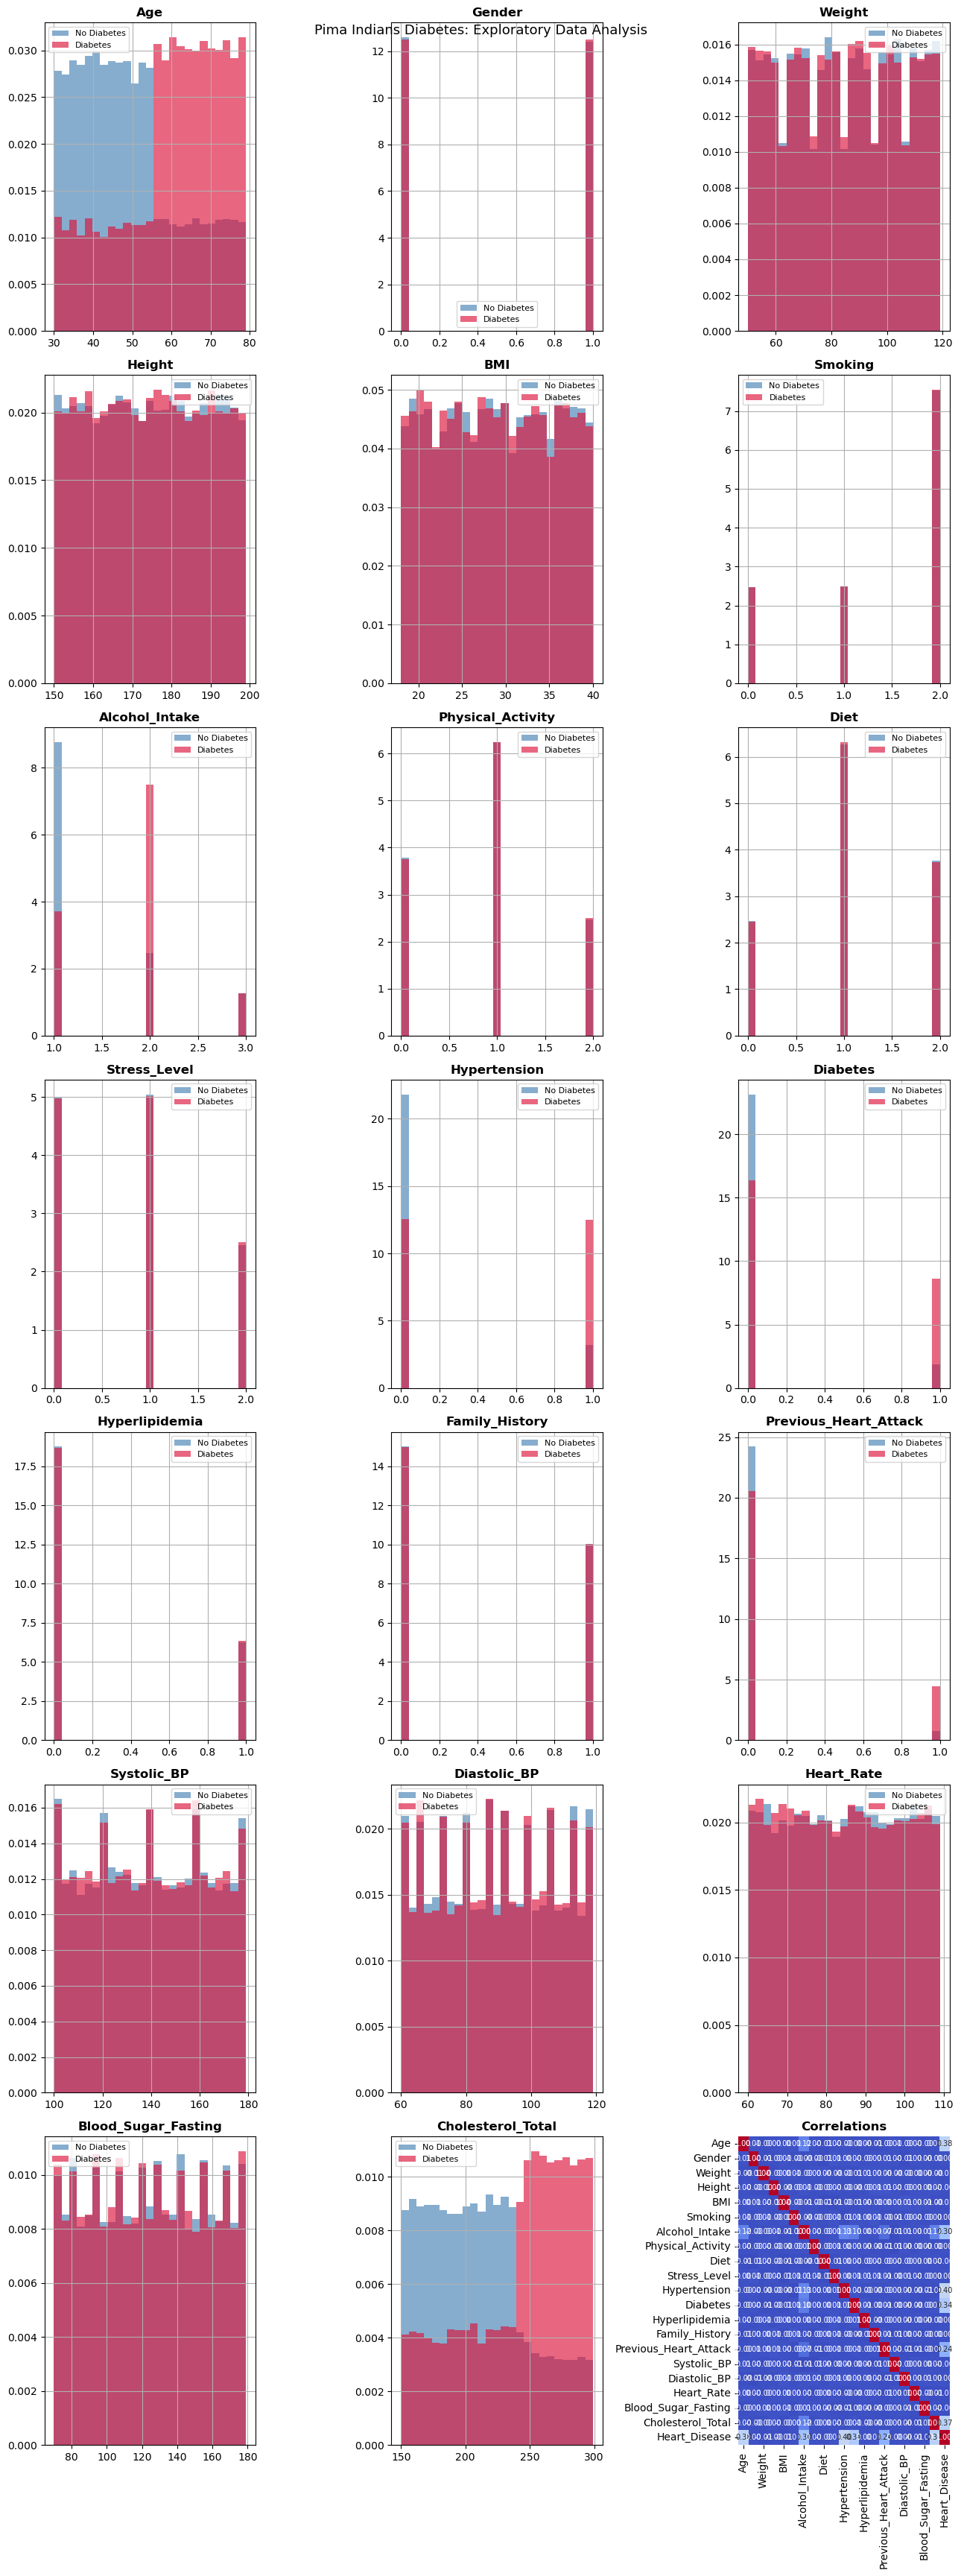

In [21]:

FEATURES = ['Age', 'Gender', 'Weight', 'Height', 'BMI', 'Smoking', 'Alcohol_Intake',
       'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes',
       'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting',
       'Cholesterol_Total']

# total plots = number of features + 1 for correlation heatmap
n_features = len(FEATURES) + 1
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    df[df['Heart_Disease'] == 0][col].hist(ax=axes[i], bins=25, alpha=0.65,
                                      color='steelblue', label='No Heart Disease', density=True)
    df[df['Heart_Disease'] == 1][col].hist(ax=axes[i], bins=25, alpha=0.65,
                                      color='crimson', label='Heart Disease', density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

# correlation heatmap in the last subplot
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[len(FEATURES)], cbar=False, annot_kws={'size': 7})
axes[len(FEATURES)].set_title('Correlations', fontweight='bold')

# remove unused axes if any
for j in range(len(FEATURES)+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Heart Disease: Exploratory Data Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('Heart_Disease.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
X = df[FEATURES].values.astype(np.float32)
y = df['Heart_Disease'].values.astype(np.float32)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=random_seed)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=random_seed)

print(f"Train: {len(X_train):>4} rows  ({y_train.mean():.1%} positive)")
print(f"Val:   {len(X_val):>4} rows  ({y_val.mean():.1%} positive)")
print(f"Test:  {len(X_test):>4} rows  ({y_test.mean():.1%} positive)")


Train: 35020 rows  (46.3% positive)
Val:   7480 rows  (46.4% positive)
Test:  7500 rows  (46.3% positive)


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Example, first row before and after:")
print("Before:", X_train[0][:5])
print("After: ", X_train_scaled[0][:5].round(2))



Scaling done. Example, first row before and after:
Before: [ 59.    1.  117.  198.   32.3]
After:  [0.31 1.01 1.6  1.63 0.52]


In [24]:
import json

# --- CSV: scaled features + target, one file per split ---
train_df = pd.DataFrame(X_train_scaled, columns=FEATURES)
train_df['Heart_Disease'] = y_train

val_df = pd.DataFrame(X_val_scaled, columns=FEATURES)
val_df['Heart_Disease'] = y_val

test_df = pd.DataFrame(X_test_scaled, columns=FEATURES)
test_df['Heart_Disease'] = y_test

train_df.to_csv('Heart_Disease_train.csv', index=False)
val_df.to_csv('Heart_Disease_val.csv', index=False)
test_df.to_csv('Heart_Disease_test.csv', index=False)

print("Saved Heart_Disease_train.csv", train_df.shape)
print("Saved Heart_Disease_val.csv  ", val_df.shape)
print("Saved Heart_Disease_test.csv ", test_df.shape)


Saved Heart_Disease_train.csv (35020, 21)
Saved Heart_Disease_val.csv   (7480, 21)
Saved Heart_Disease_test.csv  (7500, 21)


In [25]:
import json
import numpy as np

# --- JSON: feature names, medians, and the scaler's numbers ---
# Assuming X_train is your training dataframe or NumPy array

# Compute medians safely and cast to float
train_medians = dict(zip(FEATURES, np.median(X_train, axis=0).astype(float)))

# Build metadata dictionary with proper float conversion
metadata = {
    'feature': FEATURES,
    'train_medians': {k: float(v) for k, v in train_medians.items()},
    'scaler_mean': [float(x) for x in scaler.mean_],
    'scaler_scale': [float(x) for x in scaler.scale_],
}

# Save to JSON
with open('Heart_Disease_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved Heart_Disease_metadata.json")


Saved Heart_Disease_metadata.json


In [27]:
# --- PKL: one convenience bundle with everything, including the scaler object ---
prepared_data = {
    'X_train': X_train_scaled,
    'X_val': X_val_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'scaler': scaler,
    'features': FEATURES,
    'train_medians': train_medians,
}

with open('Heart_Disease_prepared.pkl', 'wb') as f:
    pickle.dump(prepared_data, f)

print("Saved Heart_Disease_prepared.pkl")


Saved Heart_Disease_prepared.pkl
